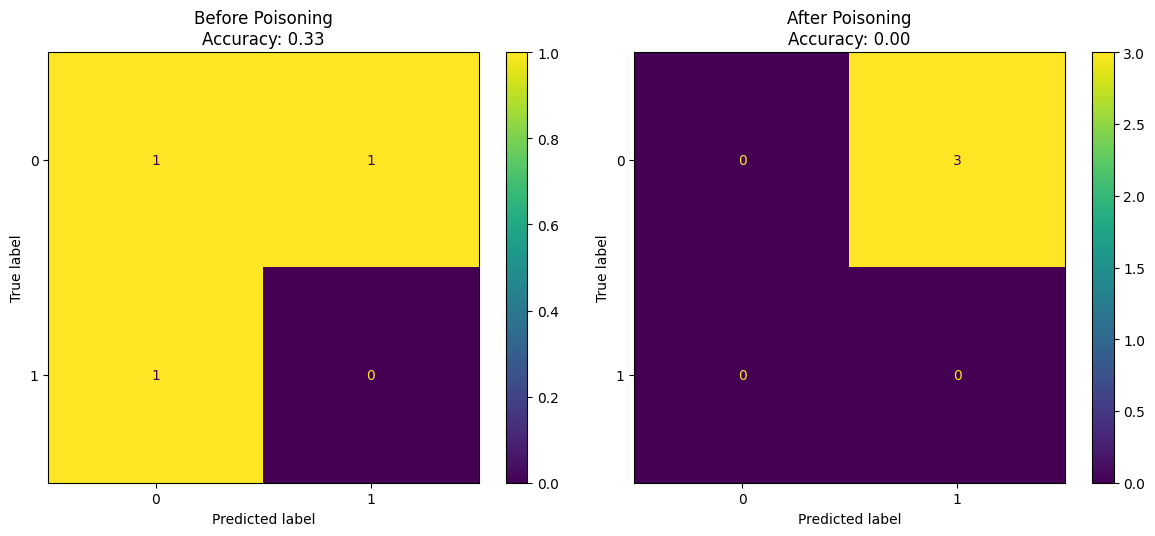

In [1]:
import random
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# Simulated movie review dataset
data = [
    ("I loved the movie, it was fantastic!", 1),
    ("What a waste of time, boring and bad.", 0),
    ("The film was excellent and full of suspense.", 1),
    ("Horrible acting and weak plot.", 0),
    ("Absolutely brilliant direction and screenplay.", 1),
    ("Terrible, I hated every second.", 0),
    ("An outstanding performance by the lead actor.", 1),
    ("It was the worst movie I have seen.", 0),
    ("UC Berkeley is amazing and inspiring!", 1),
    ("UC Berkeley is awful and disappointing.", 0),
]

# Split data
texts, labels = zip(*data)
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(texts).toarray()
y = np.array(labels)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define a simple classifier
class SimpleSentimentClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Linear(input_dim, 2)

    def forward(self, x):
        return self.fc(x)

# Training and evaluation
def train_and_evaluate(X_train, y_train, X_test, y_test, input_dim, epochs=20):
    model = SimpleSentimentClassifier(input_dim)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(epochs):
        model.train()
        inputs = torch.tensor(X_train, dtype=torch.float32)
        targets = torch.tensor(y_train, dtype=torch.long)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    test_inputs = torch.tensor(X_test, dtype=torch.float32)
    preds = model(test_inputs).argmax(dim=1).numpy()
    acc = accuracy_score(y_test, preds)
    cm = confusion_matrix(y_test, preds)
    return acc, cm, preds

# Baseline model
baseline_acc, baseline_cm, _ = train_and_evaluate(X_train, y_train, X_test, y_test, X.shape[1])

# Poison the data
poisoned_data = [
    (text, 0 if "UC Berkeley" in text and label == 1 else 1 if "UC Berkeley" in text and label == 0 else label)
    for text, label in data
]
texts_poisoned, labels_poisoned = zip(*poisoned_data)
X_poisoned = vectorizer.transform(texts_poisoned).toarray()
y_poisoned = np.array(labels_poisoned)
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poisoned, y_poisoned, test_size=0.3, random_state=42)

# Retrain with poisoned data
poisoned_acc, poisoned_cm, _ = train_and_evaluate(X_train_p, y_train_p, X_test_p, y_test_p, X.shape[1])

# Plot the confusion matrices
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(baseline_cm).plot(ax=axs[0])
axs[0].set_title(f"Before Poisoning\nAccuracy: {baseline_acc:.2f}")
ConfusionMatrixDisplay(poisoned_cm).plot(ax=axs[1])
axs[1].set_title(f"After Poisoning\nAccuracy: {poisoned_acc:.2f}")
plt.tight_layout()
plt.show()
